## Practica 4: Auto-Encoder
## Exercise: Construct a simple Auto-Encoder

### 1.1 Generation of training set and validation set
### You will generate a training set and a validation set following a Sobol sampling defined as:

In [24]:
import numpy as np
from scipy.stats import qmc
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras as K
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import random

In [15]:
#1) 60,000 elements, 80% for the training setand 20% for the validation set. Be careful on how you separate
# 2) k1 ∈ [2, 5], k2 ∈ [4, 7], φ1 ∈ [0, π], φ2 ∈ [π, 2π].

total_samples = 60000
dimensions = 4 

# Initialize and generate 4D Sobol sequence
sampler = qmc.Sobol(d=dimensions, scramble=True)
sobol_sequence = sampler.random(n=total_samples)

# Define parameter bounds
lower_bounds = [2.0, 4.0, 0.0, 0.0]
upper_bounds = [5.0, 7.0, np.pi, 2 * np.pi]

# Scale [0, 1) to the new physical parameter space
scaled_params = qmc.scale(sobol_sequence, lower_bounds, upper_bounds)

In [16]:
scaled_params = qmc.scale(sobol_sequence, lower_bounds, upper_bounds)
train_size = int(total_samples * 0.8) # 48000

train_params = scaled_params[:train_size]
val_params = scaled_params[train_size:]

In [17]:
# Discretize and Generate Waveforms
def generate_datasets(params, num_x_points=128):
    x = np.linspace(0, 2 * np.pi, num_x_points)
    dataset = np.zeros((params.shape[0], num_x_points))
    
    for i in range(params.shape[0]):
        k1, k2, phi1, phi2 = params[i]
        dataset[i] = 0.25 * (np.cos(x * k1 + phi1) + np.cos(x * k2 + phi2) + 2)
        
    return dataset

# Generate final inputs for the Auto-Encoder
X_train = generate_datasets(train_params)
X_val = generate_datasets(val_params)

print(f"Training dataset ready: {X_train.shape}")
print(f"Validation dataset ready: {X_val.shape}")
print(f"Min value: {np.min(X_train):.3f}, Max value: {np.max(X_train):.3f}")

Training dataset ready: (48000, 128)
Validation dataset ready: (12000, 128)
Min value: 0.000, Max value: 1.000


### 1.2 Create your first Auto-Encoder

In [20]:
class Autoencoder(Model):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim
        
       # ENCODER: Compresses the 128-point wave down to 15
        self.encoder = tf.keras.Sequential([
            layers.Flatten(),
            layers.Dense(50, activation='relu'),
            layers.Dense(latent_dim, activation='relu') 
        ])        
        # DECODER: Reconstructs the 128-point wave from 15
        self.decoder = tf.keras.Sequential([
            layers.Dense(50, activation='relu'),
            layers.Dense(128, activation='sigmoid') 
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [ ]:
latent_dim = 15
autoencoder = Autoencoder(latent_dim)
optimizer = K.optimizers.Adam(learning_rate=0.001)
autoencoder.compile(optimizer=optimizer, loss='mean_squared_error')
autoencoder.build((None, 128))

/opt/anaconda3/envs/sbi_39/lib/python3.9/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'autoencoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
autoencoder.summary()

Model: "autoencoder_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 2 Create a Denoiser

In [ ]:
class TargetLossCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('loss') < 0.001 and logs.get('val_loss') < 0.001:
            self.model.stop_training = True

#  Train the Auto-Encoder
epochs = 500 
batch_size = 256

history = autoencoder.fit(X_train, X_train, epochs=epochs, batch_size=batch_size, shuffle=True,
    validation_data=(X_val, X_val), callbacks=[TargetLossCallback()], verbose=1
)

Epoch 1/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0484 - val_loss: 0.0100
Epoch 2/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step - loss: 0.0078 - val_loss: 0.0064
Epoch 3/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step - loss: 0.0057 - val_loss: 0.0039
Epoch 4/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - loss: 0.0038 - val_loss: 0.0037
Epoch 5/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - loss: 0.0037 - val_loss: 0.0036
Epoch 6/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - loss: 0.0036 - val_loss: 0.0034
Epoch 7/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step - loss: 0.0032 - val_loss: 0.0029
Epoch 8/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - loss: 0.0027 - val_loss: 0.0024
Epoch 9/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step - loss: 0.0024 - val_loss: 0.0022
Epoch 10/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step - loss: 0.0022 - val_loss: 0.0021
Epoch 11/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step - loss: 0.0021 - val_loss: 0.0020
Epoch 12/500
188/188 

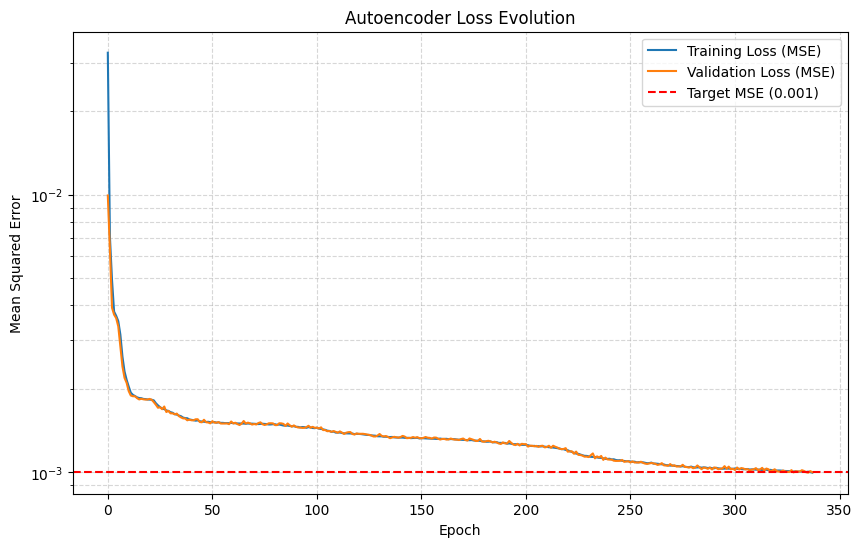

In [28]:
# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.axhline(y=0.001, color='r', linestyle='--', label='Target MSE (0.001)')

plt.title('Autoencoder Loss Evolution')
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 217us/step


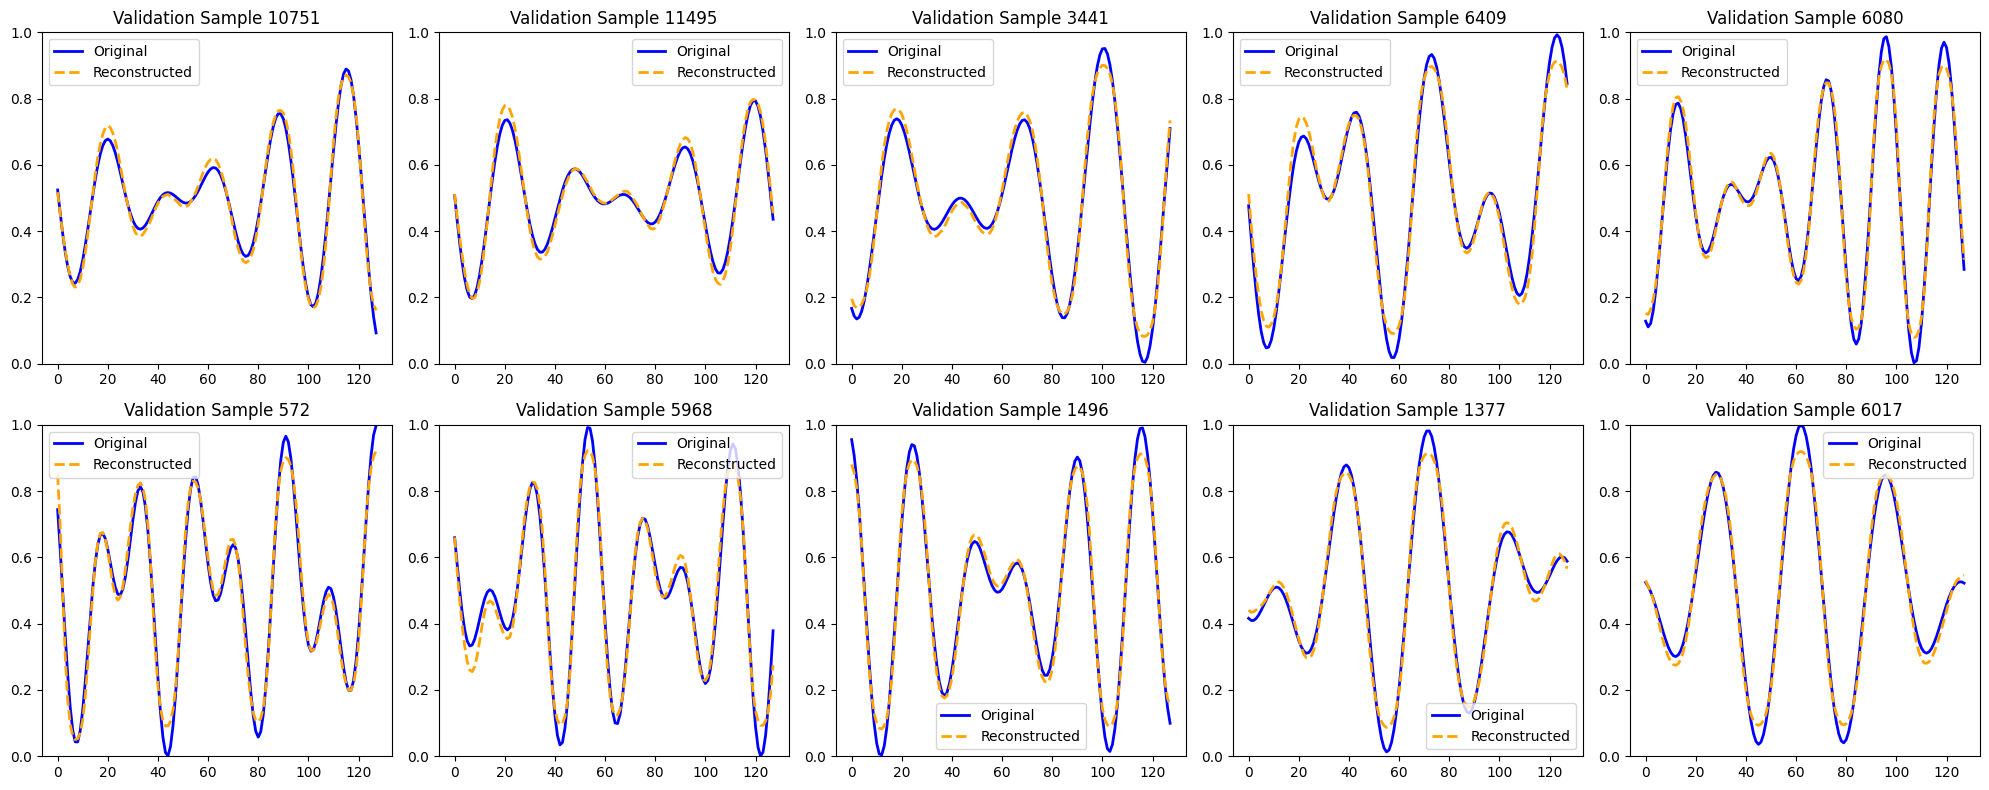

In [29]:
# Generate the reconstructed waves for the entire validation set
reconstructed_waves = autoencoder.predict(X_val)

# Select 10 random indices from the validation set
random_indices = random.sample(range(len(X_val)), 10)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    # Plot Original Data
    axes[i].plot(X_val[idx], label='Original', color='blue', linewidth=2)
    # Plot Reconstructed Data
    axes[i].plot(reconstructed_waves[idx], label='Reconstructed', color='orange', linestyle='dashed', linewidth=2)
    
    axes[i].set_title(f"Validation Sample {idx}")
    axes[i].set_ylim(0, 1) # Keep y-axis consistent with our bounds
    axes[i].legend()

plt.tight_layout()
plt.show()

### Yes, these comparisons look excellent. The reconstructed waves trace the original signals with high fidelity, accurately capturing both the low and high-frequency components along with their respective phase shifts. 

### 2 Create a Denoiser

In [31]:
#Create function, apply to copies
def add_gaussian_noise(data, std_dev=0.1):
    """Adds Gaussian noise and clips the result to [0, 1]."""
    noise = np.random.normal(loc=0.0, scale=std_dev, size=data.shape)
    noisy_data = data + noise
    return np.clip(noisy_data, 0., 1.)

X_train_noise = add_gaussian_noise(X_train, std_dev=0.1)
X_val_noise = add_gaussian_noise(X_val, std_dev=0.1)

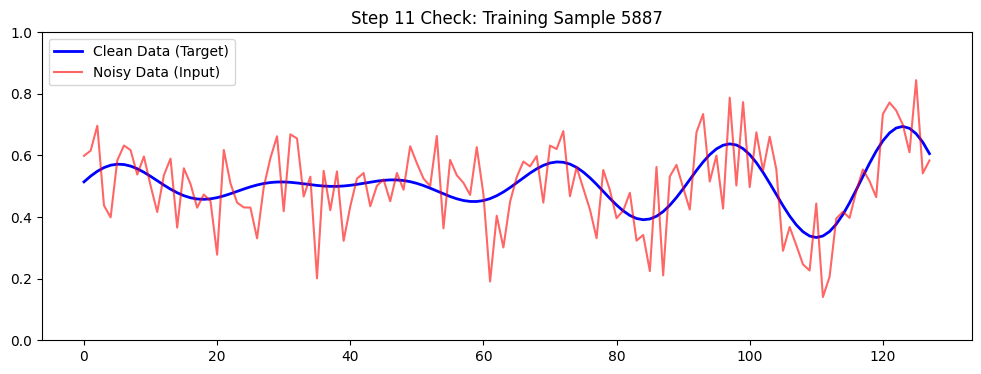

In [32]:
# Check examples by plotting Noisy vs. Clean
plt.figure(figsize=(12, 4))
idx = random.randint(0, len(X_train) - 1)

plt.plot(X_train[idx], label='Clean Data (Target)', color='blue', linewidth=2)
plt.plot(X_train_noise[idx], label='Noisy Data (Input)', color='red', alpha=0.6)
plt.title(f"Step 11 Check: Training Sample {idx}")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [33]:
latent_dim = 15
denoiser = Autoencoder(latent_dim)
denoiser.compile(optimizer=K.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')
denoiser.build((None, 128))

# Define the callback for the new MSE target (< 0.002)
class DenoiseTargetLossCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('loss') < 0.002 and logs.get('val_loss') < 0.002:
            print(f"\nSuccess! Reached MSE < 0.002 at epoch {epoch+1}. Stopping training.")
            self.model.stop_training = True

history_denoise = denoiser.fit(x=X_train_noise, y=X_train, epochs=500, batch_size=256, shuffle=True,
                                validation_data=(X_val_noise, X_val), callbacks=[DenoiseTargetLossCallback()], verbose=1)

Epoch 1/500


/opt/anaconda3/envs/sbi_39/lib/python3.9/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'autoencoder_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0474 - val_loss: 0.0132
Epoch 2/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - loss: 0.0098 - val_loss: 0.0045
Epoch 3/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step - loss: 0.0040 - val_loss: 0.0030
Epoch 4/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step - loss: 0.0028 - val_loss: 0.0022
Epoch 5/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - loss: 0.0022 - val_loss: 0.0021
Epoch 6/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - loss: 0.0021 - val_loss: 0.0021
Epoch 7/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 8/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 871us/step - loss: 0.0021 - val_loss: 0.0021
Epoch 9/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step - loss: 0.0021 - val_loss: 0.0021
Epoch 10/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step - loss: 0.0021 - val_loss: 0.0021
Epoch 11/500
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - loss: 0.0020 - val_loss: 0.0021
Epoch 12/500
188/188 ━━━━━━━━━━━━━━

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 213us/step


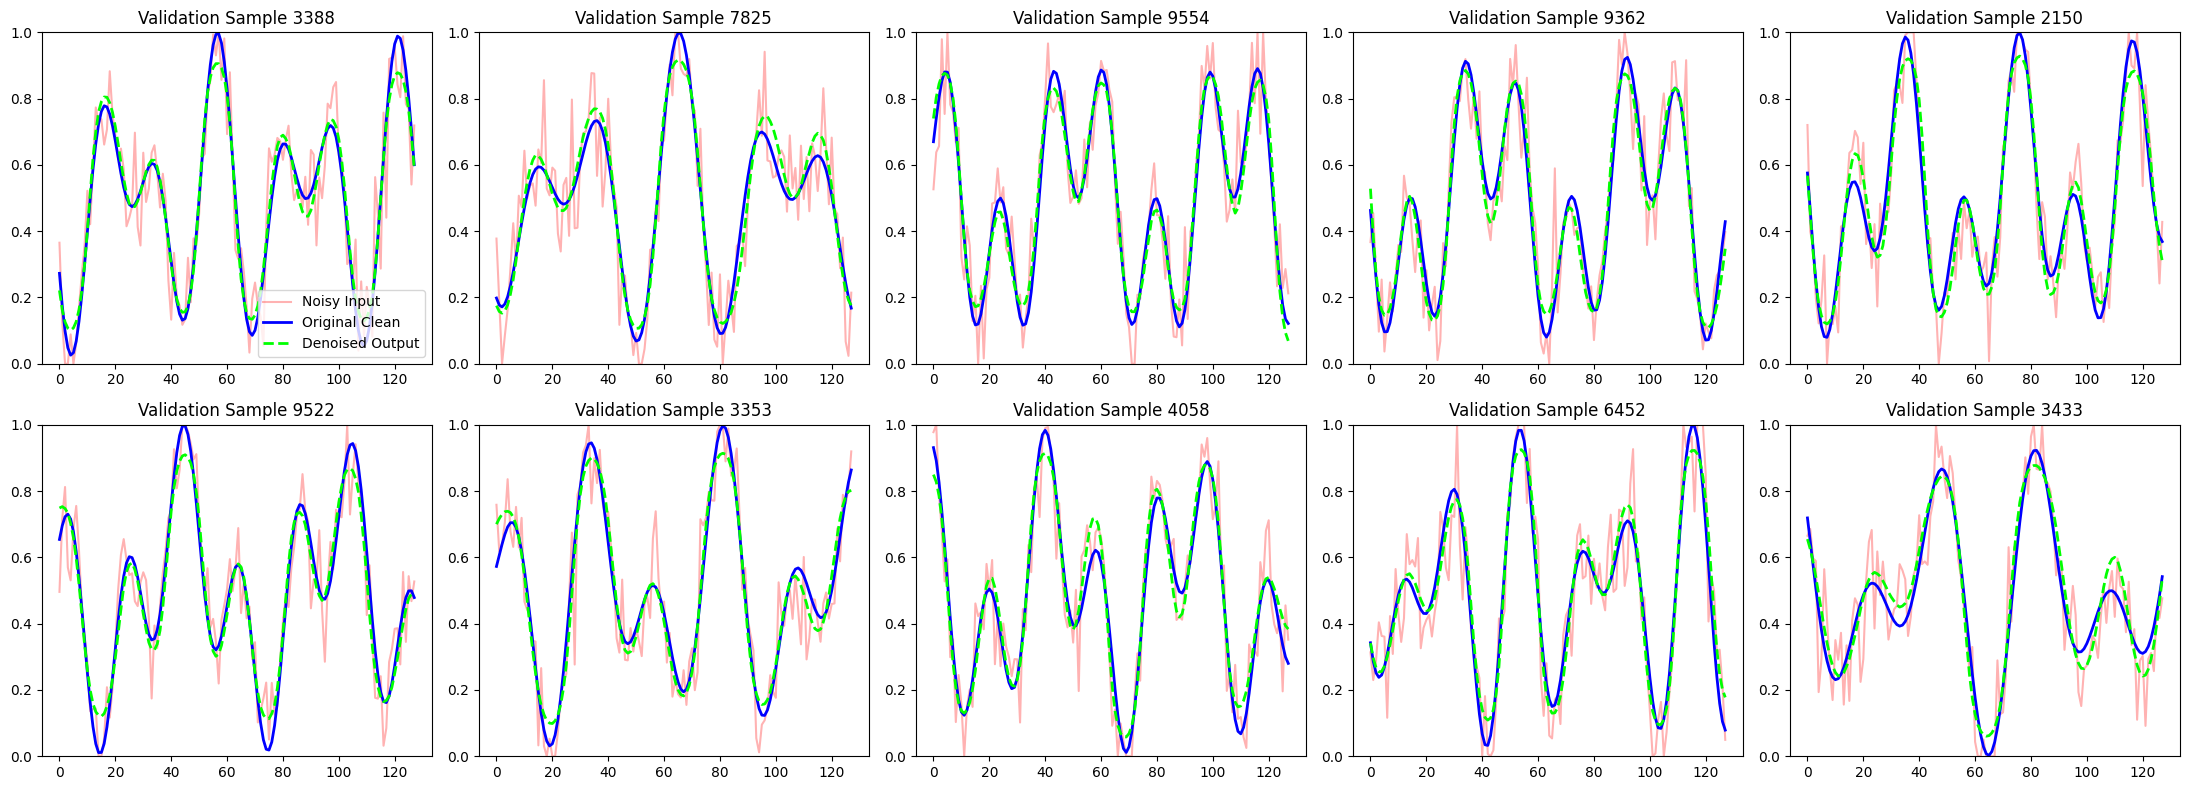

In [36]:
# Apply encoder and decoder to noised validation data
denoised_waves = denoiser.predict(X_val_noise)
random_indices = random.sample(range(len(X_val_noise)), 10)

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    axes[i].plot(X_val_noise[idx], label='Noisy Input', color='red', alpha=0.3)
    axes[i].plot(X_val[idx], label='Original Clean', color='blue', linewidth=2)
    axes[i].plot(denoised_waves[idx], label='Denoised Output', color='lime', linestyle='dashed', linewidth=2)
    
    axes[i].set_title(f"Validation Sample {idx}")
    axes[i].set_ylim(0, 1)

    if i == 0:
        axes[i].legend(loc='lower right')

plt.tight_layout()
plt.show()